# 06 — End-to-end streaming run, multi-strategy comparison

The digital twin streams real DE-LU prices and a manually-listed appliance-onset stream, ticking **N independent strategies** in parallel.  Each strategy is a self-contained agent that maintains its own state and accrues its own cost.

**Default strategies:**
- `baseline` — naive ASAP household policy (no price awareness): EV charges at full rated power from plug-in until full, heater runs at rated power until each window's kWh requirement is met, cycles start immediately at onset.
- `optimizer` — MPC + LangGraph + HITL gating: EV/heater shifted to cheap slots, cycles offered for reschedule.

**The only inter-strategy coordination** is *cross-strategy onset gating*: a new onset for an appliance is suppressed if **any** strategy still has that appliance pending or running. This prevents an unrealistic phantom second cycle when one strategy has finished while another has deferred.

**Outputs (written to `data/cache/`):**
- `slot_log.parquet` — 15-min slots, every strategy's power profile + cumulative cost (column-prefixed by strategy name).
- `event_log.parquet` — 1-second decision log; uniform schema across strategies, includes stream-level `onset_permitted` / `onset_suppressed` events.
- `run_log.jsonl` — OptimizerStrategy's per-replan log with full plan detail.

This notebook injects three onsets to demonstrate the loop:
- dishwasher at +1 h
- washing machine at +2 h 15 min
- second dishwasher at +3 h — **deliberately suppressed** (the optimizer is still running the first dishwasher cycle).

In [1]:
import subprocess, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Deterministic 24h simulation with three onsets. The third dishwasher
# onset (+3h) deliberately falls inside the optimizer's pending window
# for the first dishwasher (+1h, 2h cycle, accept policy can defer up
# to 2h) so we can demonstrate the cross-strategy gating.



# twin.APPLIANCE_ONSETS = (
#     ("dishwasher",      start + timedelta(hours=1, minutes=0)),
#     ("washing_machine", start + timedelta(hours=2, minutes=15)),
#     ("dishwasher",      start + timedelta(hours=3, minutes=0)),  # may be suppressed
#     ("washing_machine", start + timedelta(hours=7, minutes=25)),
#     ("washing_machine", start + timedelta(hours=14, minutes=25)),
#     ("dishwasher",      start + timedelta(hours=30, minutes=16)),
#     ("washing_machine", start + timedelta(hours=40, minutes=44)),
#     ("dishwasher",      start + timedelta(hours=46, minutes=55)),
# )
script = r"""
from datetime import timedelta
import aerogrid.sim.digital_twin as twin

start = twin.SIM_TEST_START.replace(hour=20, minute=0, second=0, microsecond=0)
twin.SIM_TEST_START = start


import sys
sys.argv = ["digital_twin", "--hours", "48"]
raise SystemExit(twin.main())
"""
subprocess.run([sys.executable, "-c", script], check=True)



=== simulation summary ===
samples:                    172,800
onsets suppressed:          2
slot log:                   /Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/data/cache/slot_log.parquet
event log:                  /Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/data/cache/event_log.parquet

strategy         cost (€)   detail
baseline            3.707   
optimizer          -0.127   n_replans=1558, n_hitl=0, n_reschedule_accept=2, n_reschedule_decline=5, last_replan_reason=15.0m since last

  optimizer vs baseline savings: +103.4%


CompletedProcess(args=['/Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/.venv/bin/python', '-c', '\nfrom datetime import timedelta\nimport aerogrid.sim.digital_twin as twin\n\nstart = twin.SIM_TEST_START.replace(hour=20, minute=0, second=0, microsecond=0)\ntwin.SIM_TEST_START = start\n\n\nimport sys\nsys.argv = ["digital_twin", "--hours", "48"]\nraise SystemExit(twin.main())\n'], returncode=0)

strategies discovered: ['baseline', 'optimizer']
slot log:  192 rows × 24 cols
event log: 2857 rows
event counts by strategy: {'optimizer': 2793, 'baseline': 50, 'stream': 14}

final cumulative cost:
  baseline     €  3.707
  optimizer    € -0.127
  optimizer vs baseline: +103.4% savings
  injected onsets suppressed: 2


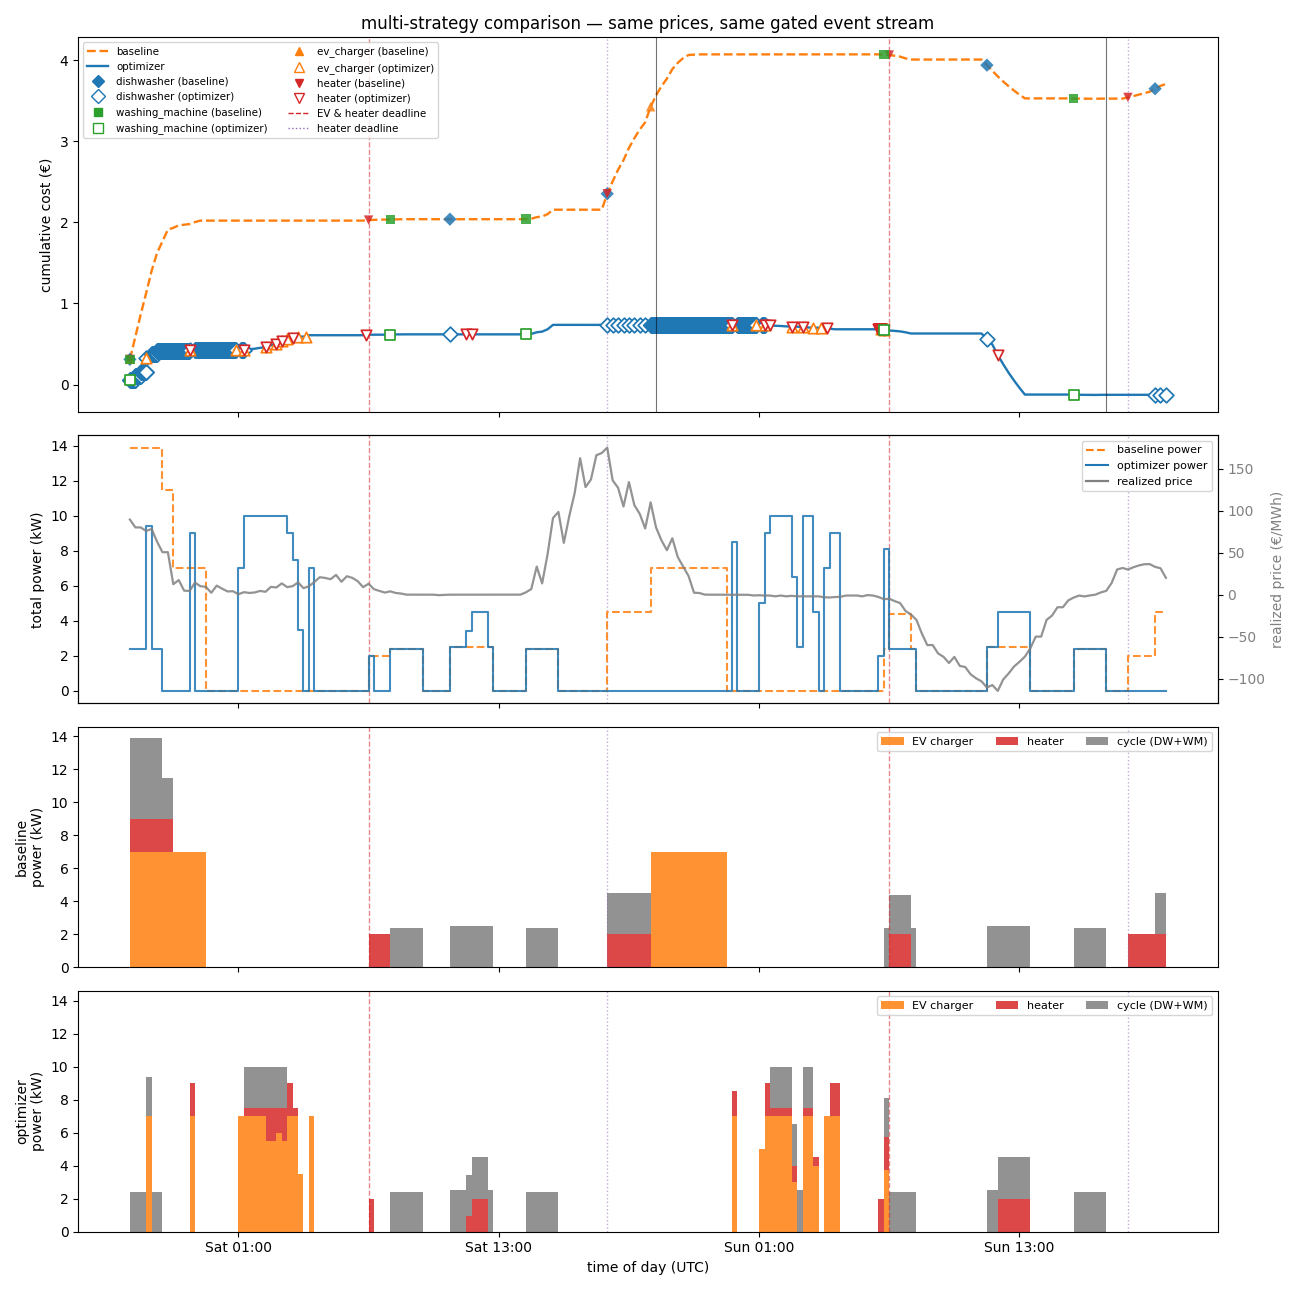

In [2]:
"""Multi-strategy plotting.

Top panel    cumulative cost per strategy + activation markers + suppressed onsets.
Mid panel    total power per strategy (left axis, step plot) overlaid on the
             realized price (right axis). This is the story of optimization:
             where the price is low the optimizer parks load, the baseline
             ignores price entirely.
Per-strategy stacked panels (one per strategy) break the total down into
             EV / heater / cycle so you can see *which* appliance moves where.

EV and heater deadlines are drawn as vertical dashed lines on every panel so
you can see *when* each load must be done and how the schedules align with
those deadlines.  The x-axis is wall-clock time of day, not relative hours.
"""
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython import get_ipython
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from aerogrid.config import (
    SLOT_LOG_PATH, EVENT_LOG_PATH,
    EV_DEADLINE_HOUR, HEATER_DEADLINES,
)

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
    except Exception:
        pass

slot_df  = pd.read_parquet(SLOT_LOG_PATH)
event_df = pd.read_parquet(EVENT_LOG_PATH)
slot_df["timestamp"]  = pd.to_datetime(slot_df["timestamp"], utc=True)
event_df["timestamp"] = pd.to_datetime(event_df["timestamp"], utc=True)
slot_df  = slot_df.sort_values("timestamp").reset_index(drop=True)
event_df = event_df.sort_values("timestamp").reset_index(drop=True)

# Discover strategies from the slot-log column suffixes.
strategy_names = [
    m.group(1)
    for m in (re.match(r"(.+)_cum_cost_eur$", c) for c in slot_df.columns)
    if m is not None
]
print(f"strategies discovered: {strategy_names}")
print(f"slot log:  {len(slot_df)} rows × {len(slot_df.columns)} cols")
print(f"event log: {len(event_df)} rows")
print(f"event counts by strategy: {event_df['strategy'].value_counts().to_dict()}")

# ── X-axis formatting: daytime hours, scales with run length ─────────────────
t_min, t_max = slot_df["timestamp"].min(), slot_df["timestamp"].max()
duration_h = (t_max - t_min).total_seconds() / 3600.0
if duration_h <= 36:
    locator   = mdates.HourLocator(interval=3 if duration_h > 12 else 1)
    formatter = mdates.DateFormatter("%H:%M")
elif duration_h <= 168:
    locator   = mdates.HourLocator(interval=12)
    formatter = mdates.DateFormatter("%a %H:%M")
else:
    locator   = mdates.DayLocator()
    formatter = mdates.DateFormatter("%a %d")

# ── Deadline timestamps within the simulation window ────────────────────────
def deadline_kind(hour):
    """Return (label, color, linestyle) for a deadline at *hour*."""
    is_ev     = hour == EV_DEADLINE_HOUR
    is_heater = any(d.hour == hour for d in HEATER_DEADLINES)
    if is_ev and is_heater:
        return "EV & heater deadline", "#d62728", "--"
    if is_ev:
        return "EV deadline", "#d62728", "--"
    return "heater deadline", "#9467bd", ":"

deadline_hours = sorted({EV_DEADLINE_HOUR} | {d.hour for d in HEATER_DEADLINES})
deadlines = []
for day in pd.date_range(t_min.floor("D"), t_max.ceil("D"), freq="D", tz="UTC"):
    for hour in deadline_hours:
        t = day.replace(hour=hour, minute=0, second=0, microsecond=0)
        if t_min <= t <= t_max:
            label, color, ls = deadline_kind(hour)
            deadlines.append((t, label, color, ls))

# ── Build plot: cost + total power/price + one breakdown panel per strategy ─
n_strats = len(strategy_names)
height_ratios = [1.4, 1.0] + [0.9] * n_strats
fig, axes = plt.subplots(
    2 + n_strats, 1,
    figsize=(13, 8.5 + 2.2 * n_strats),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
ax_cost, ax_pp = axes[0], axes[1]
breakdown_axes = {name: axes[2 + i] for i, name in enumerate(strategy_names)}

# ── Top: cumulative cost ─────────────────────────────────────────────────────
curve_color = {"baseline": "C1", "optimizer": "C0"}
for name in strategy_names:
    ax_cost.plot(
        slot_df["timestamp"], slot_df[f"{name}_cum_cost_eur"],
        lw=1.7, ls="--" if name == "baseline" else "-",
        color=curve_color.get(name), label=name,
    )
ax_cost.set_ylabel("cumulative cost (€)")
ax_cost.set_title("multi-strategy comparison — same prices, same gated event stream")

# Activation markers from the event log (filled = baseline, hollow = optimizer).
ACTIVATION_TYPES = {
    "baseline":  {"ev_charging_start", "heater_on", "cycle_start"},
    "optimizer": {"ev_setpoint_changed", "heater_setpoint_changed", "cycle_committed"},
}
appliance_style = {
    "dishwasher":      {"marker": "D", "color": "#1f77b4"},
    "washing_machine": {"marker": "s", "color": "#2ca02c"},
    "ev_charger":      {"marker": "^", "color": "#ff7f0e"},
    "heater":          {"marker": "v", "color": "#d62728"},
}
def attach_cum_cost(ev, name):
    return pd.merge_asof(
        ev.sort_values("timestamp"),
        slot_df[["timestamp", f"{name}_cum_cost_eur"]].rename(
            columns={f"{name}_cum_cost_eur": "y_cost"}),
        on="timestamp", direction="backward",
    )
for name in strategy_names:
    types = ACTIVATION_TYPES.get(name)
    if types is None:
        continue
    sub = event_df[
        (event_df["strategy"] == name)
        & (event_df["event_type"].isin(types))
        & (event_df["power_kw"].fillna(1.0) > 1e-6)
    ]
    sub = attach_cum_cost(sub, name)
    filled = name == "baseline"
    for app, g in sub.groupby("appliance"):
        st = appliance_style.get(str(app), {"marker": "o", "color": "#7f7f7f"})
        if filled:
            ax_cost.scatter(g["timestamp"], g["y_cost"], marker=st["marker"], s=46,
                            facecolor=st["color"], edgecolor="none", alpha=0.85, zorder=5)
        else:
            ax_cost.scatter(g["timestamp"], g["y_cost"], marker=st["marker"], s=56,
                            facecolor="white", edgecolor=st["color"], lw=1.25, zorder=6)

# Suppressed onset markers (cost panel only — visually loud enough).
suppressed = event_df[event_df["event_type"] == "onset_suppressed"]
for _, row in suppressed.iterrows():
    ax_cost.axvline(row["timestamp"], color="black", alpha=0.55, lw=0.8, zorder=7)

# Deadline lines on EVERY panel.
seen_kinds = {}
for t, label, color, ls in deadlines:
    seen_kinds.setdefault(label, (color, ls))
    for ax in axes:
        ax.axvline(t, color=color, ls=ls, lw=1.0, alpha=0.55)

# Cost-panel legend.
cost_handles = [
    Line2D([0], [0], color=curve_color.get(n), ls="--" if n == "baseline" else "-",
           lw=1.7, label=n) for n in strategy_names
]
for app, st in appliance_style.items():
    cost_handles.extend([
        Line2D([0], [0], marker=st["marker"], color="w",
               markerfacecolor=st["color"], markeredgecolor=st["color"],
               ms=6, label=f"{app} (baseline)"),
        Line2D([0], [0], marker=st["marker"], color="w",
               markerfacecolor="white", markeredgecolor=st["color"],
               ms=7, label=f"{app} (optimizer)"),
    ])
for label, (color, ls) in seen_kinds.items():
    cost_handles.append(Line2D([0], [0], color=color, ls=ls, lw=1.0, label=label))
ax_cost.legend(handles=cost_handles, loc="upper left", fontsize=7.4, ncol=2)

# ── Mid: total power per strategy (left) + realized price (right) ──────────
ax_power = ax_pp
ax_price = ax_pp.twinx()

for name in strategy_names:
    ax_power.step(
        slot_df["timestamp"], slot_df[f"{name}_total_kw"],
        where="post", lw=1.5,
        ls="--" if name == "baseline" else "-",
        color=curve_color.get(name), alpha=0.85,
    )
ax_power.set_ylabel("total power (kW)")

ax_price.plot(
    slot_df["timestamp"], slot_df["price_eur_mwh"],
    color="grey", lw=1.6, alpha=0.85,
)
ax_price.set_ylabel("realized price (€/MWh)", color="grey")
ax_price.tick_params(axis="y", labelcolor="grey")

pp_handles = [
    Line2D([0], [0], color=curve_color.get(n), ls="--" if n == "baseline" else "-",
           lw=1.5, label=f"{n} power") for n in strategy_names
]
pp_handles.append(Line2D([0], [0], color="grey", lw=1.6, label="realized price"))
ax_pp.legend(handles=pp_handles, loc="upper right", fontsize=8)

# ── Per-strategy appliance breakdown (stacked area) ─────────────────────────
# The cycle column lumps dishwasher and washing_machine together at the slot
# log level (per-cycle attribution lives in the event log), so we colour it as
# a single neutral category.
breakdown_layers = [
    ("ev_kw",     "EV charger", appliance_style["ev_charger"]["color"]),
    ("heater_kw", "heater",     appliance_style["heater"]["color"]),
    ("cycle_kw",  "cycle (DW+WM)", "#7f7f7f"),
]
shared_y_max = max(
    slot_df[f"{name}_total_kw"].max() for name in strategy_names
) * 1.05

for name in strategy_names:
    ax = breakdown_axes[name]
    series = [slot_df[f"{name}_{col}"].values for col, _, _ in breakdown_layers]
    colors = [c for _, _, c in breakdown_layers]
    labels = [lbl for _, lbl, _ in breakdown_layers]
    ax.stackplot(
        slot_df["timestamp"], *series,
        labels=labels, colors=colors, alpha=0.85, step="post",
    )
    ax.set_ylabel(f"{name}\npower (kW)")
    ax.set_ylim(0, shared_y_max)
    ax.legend(
        handles=[Patch(facecolor=c, label=lbl, alpha=0.85)
                 for _, lbl, c in breakdown_layers],
        loc="upper right", fontsize=8, ncol=len(breakdown_layers),
    )

# Apply x-axis formatter (sharex propagates to all panels).
axes[-1].set_xlabel("time of day (UTC)")
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate(rotation=0, ha="center")

# ── Final summary printout ──────────────────────────────────────────────────
print()
print("final cumulative cost:")
for name in strategy_names:
    print(f"  {name:<12} €{slot_df[f'{name}_cum_cost_eur'].iloc[-1]:>7.3f}")
if "baseline" in strategy_names:
    base = slot_df["baseline_cum_cost_eur"].iloc[-1]
    if base > 1e-9:
        for name in strategy_names:
            if name == "baseline":
                continue
            saved = (1 - slot_df[f"{name}_cum_cost_eur"].iloc[-1] / base) * 100
            print(f"  {name} vs baseline: {saved:+.1f}% savings")
print(f"  injected onsets suppressed: {len(suppressed)}")

plt.tight_layout()
plt.show()


In [3]:
# ── Slot log: 15-min resolution, side-by-side per strategy ────────────────────
core_cols = ["timestamp", "price_eur_mwh", "onsets", "suppressed_onsets"]
print("=== slot_log (first 12 rows, sample columns) ===")
sample_cols = core_cols.copy()
for name in strategy_names:
    sample_cols.extend([
        f"{name}_ev_kw", f"{name}_heater_kw", f"{name}_cycle_kw",
        f"{name}_cum_cost_eur",
    ])
display(slot_df[sample_cols].head(12))

# ── Event log: full per-decision log ──────────────────────────────────────────
print("\n=== event_log (per-decision, 1-second resolution) ===")
display(event_df[[
    "timestamp", "strategy", "event_type", "appliance",
    "power_kw", "remaining_ev_kwh", "cum_cost_eur",
    "price_eur_mwh", "detail",
]])

# ── Cross-strategy event counts ───────────────────────────────────────────────
print("\n=== events by strategy × event_type ===")
display(
    event_df.groupby(["strategy", "event_type"])
    .size().rename("count")
    .reset_index()
    .sort_values(["strategy", "count"], ascending=[True, False])
)

# ── Suppression detail (the cross-strategy gating in action) ──────────────────
suppressed = event_df[event_df["event_type"] == "onset_suppressed"]
if not suppressed.empty:
    print(f"\n=== suppressed onsets ({len(suppressed)}) ===")
    display(suppressed[["timestamp", "appliance", "detail"]])
else:
    print("\nNo onsets were suppressed in this run.")


=== slot_log (first 12 rows, sample columns) ===


,timestamp,price_eur_mwh,onsets,suppressed_onsets,baseline_ev_kw,baseline_heater_kw,baseline_cycle_kw,baseline_cum_cost_eur,optimizer_ev_kw,optimizer_heater_kw,optimizer_cycle_kw,optimizer_cum_cost_eur
0,2026-04-03 20:00:00+00:00,89.35,"dishwasher,washing_machine",,7.0,2.0,4.9,0.310491,0.0,0.0,2.4,0.053610
1,2026-04-03 20:15:00+00:00,80.05,,,7.0,2.0,4.9,0.588665,0.0,0.0,2.4,0.101640
2,2026-04-03 20:30:00+00:00,79.98,,,7.0,2.0,4.9,0.866596,0.0,0.0,2.4,0.149628
3,2026-04-03 20:45:00+00:00,75.74,,,7.0,2.0,4.9,1.129792,7.0,0.0,2.4,0.327617
4,2026-04-03 21:00:00+00:00,78.19,,,7.0,2.0,4.9,1.401502,0.0,0.0,2.4,0.374531
5,2026-04-03 21:15:00+00:00,63.14,,,7.0,2.0,4.9,1.620914,0.0,0.0,2.4,0.412415
6,2026-04-03 21:30:00+00:00,50.49,,,7.0,2.0,2.5,1.766073,0.0,0.0,0.0,0.412415
7,2026-04-03 21:45:00+00:00,50.53,,,7.0,2.0,2.5,1.911346,0.0,0.0,0.0,0.412415
8,2026-04-03 22:00:00+00:00,12.44,,,7.0,0.0,0.0,1.933116,0.0,0.0,0.0,0.412415
9,2026-04-03 22:15:00+00:00,17.35,,,7.0,0.0,0.0,1.963479,0.0,0.0,0.0,0.412415



=== event_log (per-decision, 1-second resolution) ===


,timestamp,strategy,event_type,appliance,power_kw,remaining_ev_kwh,cum_cost_eur,price_eur_mwh,detail
0,2026-04-03 07:30:00+00:00,stream,onset_permitted,washing_machine,NaN,NaN,0.000000,NaN,confidence=1.00
1,2026-04-03 09:15:00+00:00,stream,onset_permitted,dishwasher,NaN,NaN,0.000000,NaN,confidence=1.00
2,2026-04-03 13:45:00+00:00,stream,onset_permitted,washing_machine,NaN,NaN,0.000000,NaN,confidence=1.00
3,2026-04-03 17:30:00+00:00,stream,onset_permitted,dishwasher,NaN,NaN,0.000000,NaN,confidence=1.00
4,2026-04-03 20:00:00+00:00,optimizer,reschedule_proposed,washing_machine,NaN,24.0,0.000000,89.35,shift=90 min savings=€0.032 proposed_start=202...
...,...,...,...,...,...,...,...,...,...
2852,2026-04-05 19:15:00+00:00,optimizer,reschedule_accepted,dishwasher,NaN,24.0,-0.126513,33.07,start_at=2026-04-05T21:15:00+00:00 shift=120 m...
2853,2026-04-05 19:30:00+00:00,optimizer,replan_triggered,NaN,NaN,24.0,-0.126513,31.40,kind=periodic reason='15.0m since last'
2854,2026-04-05 19:30:00+00:00,optimizer,cycle_committed,dishwasher,2.5,24.0,-0.126513,31.40,start_at=2026-04-05T21:30:00+00:00 slot_offset...
2855,2026-04-05 19:45:00+00:00,optimizer,replan_triggered,NaN,NaN,24.0,-0.126513,20.02,kind=periodic reason='15.0m since last'



=== events by strategy × event_type ===


,strategy,event_type,count
8,baseline,onset_received,12
1,baseline,cycle_start,10
0,baseline,cycle_end,9
6,baseline,heater_on,5
5,baseline,heater_off,4
7,baseline,heater_window_reset,4
2,baseline,ev_charging_start,2
3,baseline,ev_charging_stop,2
4,baseline,ev_daily_reset,2
13,optimizer,replan_triggered,1558



=== suppressed onsets (2) ===


,timestamp,appliance,detail
1335,2026-04-04 20:15:00+00:00,dishwasher,blocked_by=[optimizer]
2833,2026-04-05 17:00:00+00:00,washing_machine,"blocked_by=[baseline,optimizer]"


In [5]:
# ── Smoke checks on the multi-strategy outputs ────────────────────────────────
assert not slot_df.empty,  "slot_log is empty"
assert not event_df.empty, "event_log is empty"
assert strategy_names, "no strategies discovered in slot_log columns"

# Every discovered strategy must contribute the standard column set.
for name in strategy_names:
    required = {
        f"{name}_ev_kw", f"{name}_heater_kw", f"{name}_cycle_kw",
        f"{name}_total_kw", f"{name}_slot_cost_eur", f"{name}_cum_cost_eur",
        f"{name}_remaining_ev_kwh",
    }
    missing = required - set(slot_df.columns)
    assert not missing, f"strategy {name!r} missing columns: {missing}"
    # Cumulative cost is not monotonic: DE-LU solar peaks routinely push
    # day-ahead prices negative, so a slot can pay the household.
    assert slot_df[f"{name}_cum_cost_eur"].notna().all(), (
        f"{name} cumulative cost has NaNs"
    )

# Core stream-level columns.
for col in ("timestamp", "price_eur_mwh", "onsets", "suppressed_onsets"):
    assert col in slot_df.columns, f"missing {col}"

# Event log must have entries from every strategy plus stream-level rows.
for name in strategy_names:
    assert (event_df["strategy"] == name).any(), f"no events for strategy {name!r}"
assert (event_df["strategy"] == "stream").any(), "no stream-level onset events"

# Baseline-specific event sanity (we expect these in any 24h run).
if "baseline" in strategy_names:
    base_types = set(event_df[event_df.strategy == "baseline"]["event_type"])
    assert "ev_charging_start" in base_types
    assert "heater_on" in base_types

# Optimizer-specific.
if "optimizer" in strategy_names:
    opt_types = set(event_df[event_df.strategy == "optimizer"]["event_type"])
    assert "replan_triggered" in opt_types

# Slot count consistency: 24h × 4 slots/h = 96.
assert len(slot_df) == 192, f"expected 96 slot rows, got {len(slot_df)}"

# At least one onset should be suppressed in this scenario (deliberate setup).
n_suppressed = (event_df["event_type"] == "onset_suppressed").sum()
print(f"  suppressed onsets seen:       {n_suppressed}  (expected ≥1 in this scenario)")

print("All checks passed.")
print(f"  slot_log:  {len(slot_df)} rows × {len(slot_df.columns)} cols")
print(f"  event_log: {len(event_df)} rows")
print(f"  strategies: {strategy_names}")


  suppressed onsets seen:       2  (expected ≥1 in this scenario)
All checks passed.
  slot_log:  192 rows × 24 cols
  event_log: 2857 rows
  strategies: ['baseline', 'optimizer']
